In [1]:
import json
import os
import glob
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches
from collections import OrderedDict
from collections import Counter, defaultdict, OrderedDict

import statsmodels.api as sm
from scipy.stats import norm
from scipy.interpolate import interp1d

%config InlineBackend.figure_format='retina'

In [2]:
# -- Load only manuscripts/versions listed in ../data/jids.txt --
base_path = "../manuscripts"
dfs_metrics_extract = []
dfs_metrics_eval_openeval = []

with open("../data/jids.txt") as f:
    for line in f:
        entry = line.strip()
        if not entry or "/" not in entry:
            continue
        manuscript_id, version_dir = entry.split("/")
        version = version_dir.split("-")[-1]
        manuscript_path = os.path.join(base_path, manuscript_id, version)
        
        # Load metrics_extract.json
        metrics_extract_path = os.path.join(manuscript_path, "metrics_extract.json")
        if os.path.exists(metrics_extract_path):
            with open(metrics_extract_path, "r") as metrics_extract_file:
                metrics_extract = json.load(metrics_extract_file)
            # In this project, sometimes metrics_extract is a list of dicts, where
            # each dict can be a DataFrame, or sometimes a list of DataFrames (!).
            # Sometimes it's just a dict (single record), sometimes a list of dicts,
            # sometimes a list of DataFrames? But you want a flat list of DataFrames
            # in dfs_metrics_extract, so check for these options:
            # (see notebook_cell_output_0)

            # If it's a list and all elements are dicts, each is a single record
            if isinstance(metrics_extract, list):
                # If each element is itself a dict, treat each as record
                if all(isinstance(x, dict) for x in metrics_extract):
                    df_extract_part = pd.DataFrame(metrics_extract)
                    df_extract_part["manuscript_id"] = manuscript_id
                    df_extract_part["version"] = version
                    dfs_metrics_extract.append(df_extract_part)
                # If it's a list of DataFrames, extend directly (not likely for JSON, would need pickle)
                elif all(isinstance(x, pd.DataFrame) for x in metrics_extract):
                    for dfpart in metrics_extract:
                        dfpart["manuscript_id"] = manuscript_id
                        dfpart["version"] = version
                        dfs_metrics_extract.append(dfpart)
                else:
                    # fallback: try to concat as much as possible
                    for x in metrics_extract:
                        if isinstance(x, dict):
                            df_part = pd.DataFrame([x])
                        elif isinstance(x, pd.DataFrame):
                            df_part = x
                        else:
                            continue
                        df_part["manuscript_id"] = manuscript_id
                        df_part["version"] = version
                        dfs_metrics_extract.append(df_part)
            elif isinstance(metrics_extract, dict):
                df_extract_part = pd.DataFrame([metrics_extract])
                df_extract_part["manuscript_id"] = manuscript_id
                df_extract_part["version"] = version
                dfs_metrics_extract.append(df_extract_part)
            # If it's already a DataFrame (shouldn't happen for JSON), just append
            elif isinstance(metrics_extract, pd.DataFrame):
                metrics_extract["manuscript_id"] = manuscript_id
                metrics_extract["version"] = version
                dfs_metrics_extract.append(metrics_extract)
            else:
                # Unknown format, skip
                pass
        
        # Load metrics_eval_openeval.json
        metrics_eval_openeval_path = os.path.join(manuscript_path, "metrics_eval_openeval.json")
        if os.path.exists(metrics_eval_openeval_path):
            with open(metrics_eval_openeval_path, "r") as metrics_eval_openeval_file:
                metrics_eval_openeval = json.load(metrics_eval_openeval_file)
            if isinstance(metrics_eval_openeval, list):
                if all(isinstance(x, dict) for x in metrics_eval_openeval):
                    df_eval_part = pd.DataFrame(metrics_eval_openeval)
                    df_eval_part["manuscript_id"] = manuscript_id
                    df_eval_part["version"] = version
                    dfs_metrics_eval_openeval.append(df_eval_part)
                elif all(isinstance(x, pd.DataFrame) for x in metrics_eval_openeval):
                    for dfpart in metrics_eval_openeval:
                        dfpart["manuscript_id"] = manuscript_id
                        dfpart["version"] = version
                        dfs_metrics_eval_openeval.append(dfpart)
                else:
                    for x in metrics_eval_openeval:
                        if isinstance(x, dict):
                            df_part = pd.DataFrame([x])
                        elif isinstance(x, pd.DataFrame):
                            df_part = x
                        else:
                            continue
                        df_part["manuscript_id"] = manuscript_id
                        df_part["version"] = version
                        dfs_metrics_eval_openeval.append(df_part)
            elif isinstance(metrics_eval_openeval, dict):
                df_eval_part = pd.DataFrame([metrics_eval_openeval])
                df_eval_part["manuscript_id"] = manuscript_id
                df_eval_part["version"] = version
                dfs_metrics_eval_openeval.append(df_eval_part)
            elif isinstance(metrics_eval_openeval, pd.DataFrame):
                metrics_eval_openeval["manuscript_id"] = manuscript_id
                metrics_eval_openeval["version"] = version
                dfs_metrics_eval_openeval.append(metrics_eval_openeval)
            else:
                pass

# At this point, dfs_metrics_extract may be a list of dataframes, or a list containing lists of dataframes
# But according to your output, sometimes this is a list of dataframes, sometimes... a list of lists.
# Flatten if needed:
def _flat_list_of_dataframes(dfs):
    out = []
    for x in dfs:
        if isinstance(x, pd.DataFrame):
            out.append(x)
        elif isinstance(x, list):
            for y in x:
                if isinstance(y, pd.DataFrame):
                    out.append(y)
    return out

dfs_metrics_extract = _flat_list_of_dataframes(dfs_metrics_extract)
dfs_metrics_eval_openeval = _flat_list_of_dataframes(dfs_metrics_eval_openeval)

# Concatenate metrics_extract dataframes, if any
if dfs_metrics_extract:
    df_metrics_extract = pd.concat(dfs_metrics_extract, ignore_index=True)
else:
    df_metrics_extract = pd.DataFrame()

# Concatenate metrics_eval_openeval dataframes, if any
if dfs_metrics_eval_openeval:
    df_metrics_eval_openeval = pd.concat(dfs_metrics_eval_openeval, ignore_index=True)
else:
    df_metrics_eval_openeval = pd.DataFrame()

# Check for multiple versions per manuscript_id (should only be one version per manuscript)
if not df_metrics_extract.empty:
    extract_versions = df_metrics_extract.groupby("manuscript_id")["version"].nunique()
    extract_multi_version = extract_versions[extract_versions > 1]
    if not extract_multi_version.empty:
        print("WARNING: Found multiple versions for the same manuscript_id in metrics_extract data:")
        print(extract_multi_version)

if not df_metrics_eval_openeval.empty:
    eval_versions = df_metrics_eval_openeval.groupby("manuscript_id")["version"].nunique()
    eval_multi_version = eval_versions[eval_versions > 1]
    if not eval_multi_version.empty:
        print("WARNING: Found multiple versions for the same manuscript_id in metrics_eval_openeval data:")
        print(eval_multi_version)

manuscript_id
elife-96357    2
Name: version, dtype: int64
manuscript_id
elife-96357    2
Name: version, dtype: int64


In [3]:
# Remove "elife-96357" version "v1" from all dataframes
df_metrics_eval_openeval = df_metrics_eval_openeval[~((df_metrics_eval_openeval['manuscript_id'] == "elife-96357") & (df_metrics_eval_openeval['version'] == "v1"))].reset_index(drop=True)
df_metrics_extract = df_metrics_extract[~((df_metrics_extract['manuscript_id'] == "elife-96357") & (df_metrics_extract['version'] == "v1"))].reset_index(drop=True)

In [4]:
df_metrics_extract.columns

Index(['command', 'model', 'created_at', 'input_tokens', 'cached_tokens',
       'output_tokens', 'total_tokens', 'input_cost', 'cached_cost',
       'output_cost', 'total_cost', 'processing_time_sec', 'manuscript_id',
       'version'],
      dtype='object')

In [5]:
df_metrics_eval_openeval.columns

Index(['command', 'model', 'created_at', 'input_tokens', 'cached_tokens',
       'output_tokens', 'total_tokens', 'input_cost', 'cached_cost',
       'output_cost', 'total_cost', 'processing_time_sec', 'manuscript_id',
       'version'],
      dtype='object')

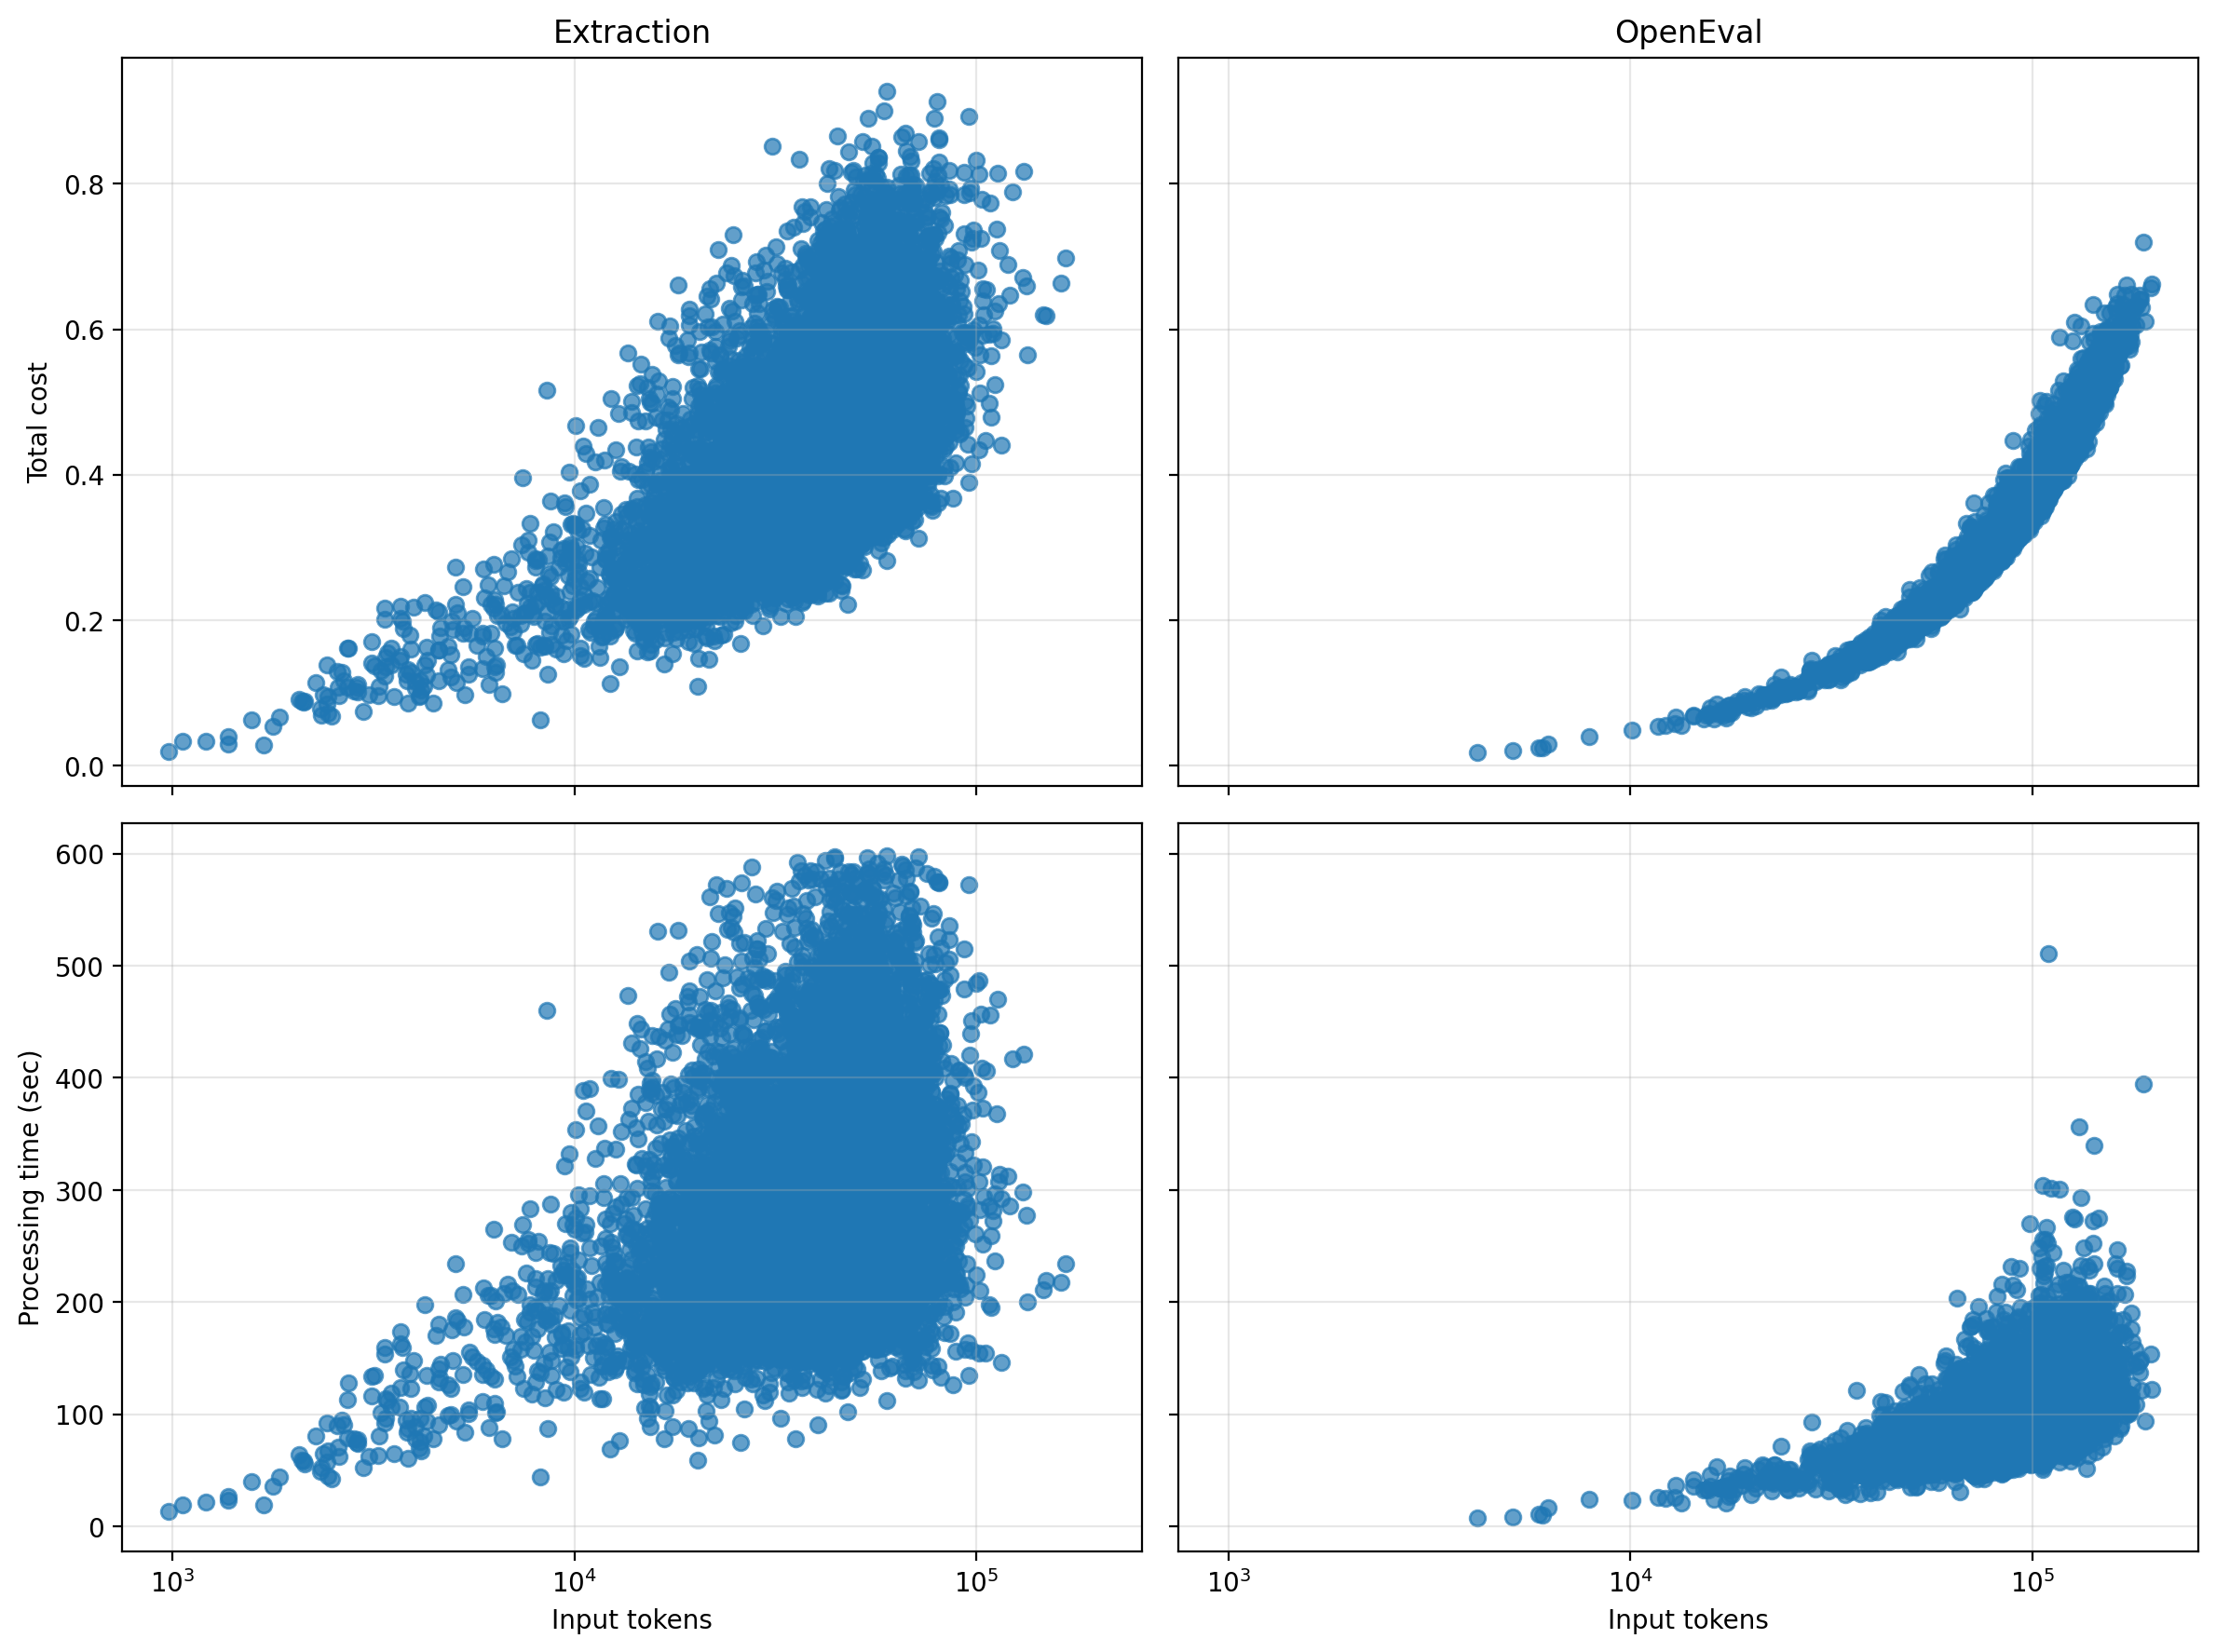

In [6]:
# Create 2x2 layout with shared x and y axes
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 9),
    sharex=True,
    sharey='row'  # Share y axis for each row (cost on top, time on bottom)
)

# --------------------------------
# Column 0: Extraction (left side)
# Column 1: OpenEval   (right side)
# Row 0: Cost vs input tokens
# Row 1: Time vs input tokens
# --------------------------------

# Cost vs input tokens - Extraction (Top left)
ax = axes[0, 0]
ax.scatter(
    df_metrics_extract["input_tokens"],
    df_metrics_extract["total_cost"],
    alpha=0.7
)
ax.set_title("Extraction")
ax.set_ylabel("Total cost")
ax.grid(alpha=0.3)
ax.set_xscale("symlog")

# Cost vs input tokens - OpenEval (Top right)
ax = axes[0, 1]
ax.scatter(
    df_metrics_eval_openeval["input_tokens"],
    df_metrics_eval_openeval["total_cost"],
    alpha=0.7
)
ax.set_title("OpenEval")
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
# Label top row x only on bottom (shared axis)

# Time vs input tokens - Extraction (Bottom left)
ax = axes[1, 0]
ax.scatter(
    df_metrics_extract["input_tokens"],
    df_metrics_extract["processing_time_sec"],
    alpha=0.7
)
ax.set_ylabel("Processing time (sec)")
ax.set_xlabel("Input tokens")
ax.grid(alpha=0.3)
ax.set_xscale("symlog")

# Time vs input tokens - OpenEval (Bottom right)
ax = axes[1, 1]
ax.scatter(
    df_metrics_eval_openeval["input_tokens"],
    df_metrics_eval_openeval["processing_time_sec"],
    alpha=0.7
)
ax.set_xlabel("Input tokens")
ax.grid(alpha=0.3)
ax.set_xscale("symlog")

# Set row titles on left Y axes
axes[0, 0].set_ylabel("Total cost")
axes[1, 0].set_ylabel("Processing time (sec)")
plt.tight_layout()
plt.show()


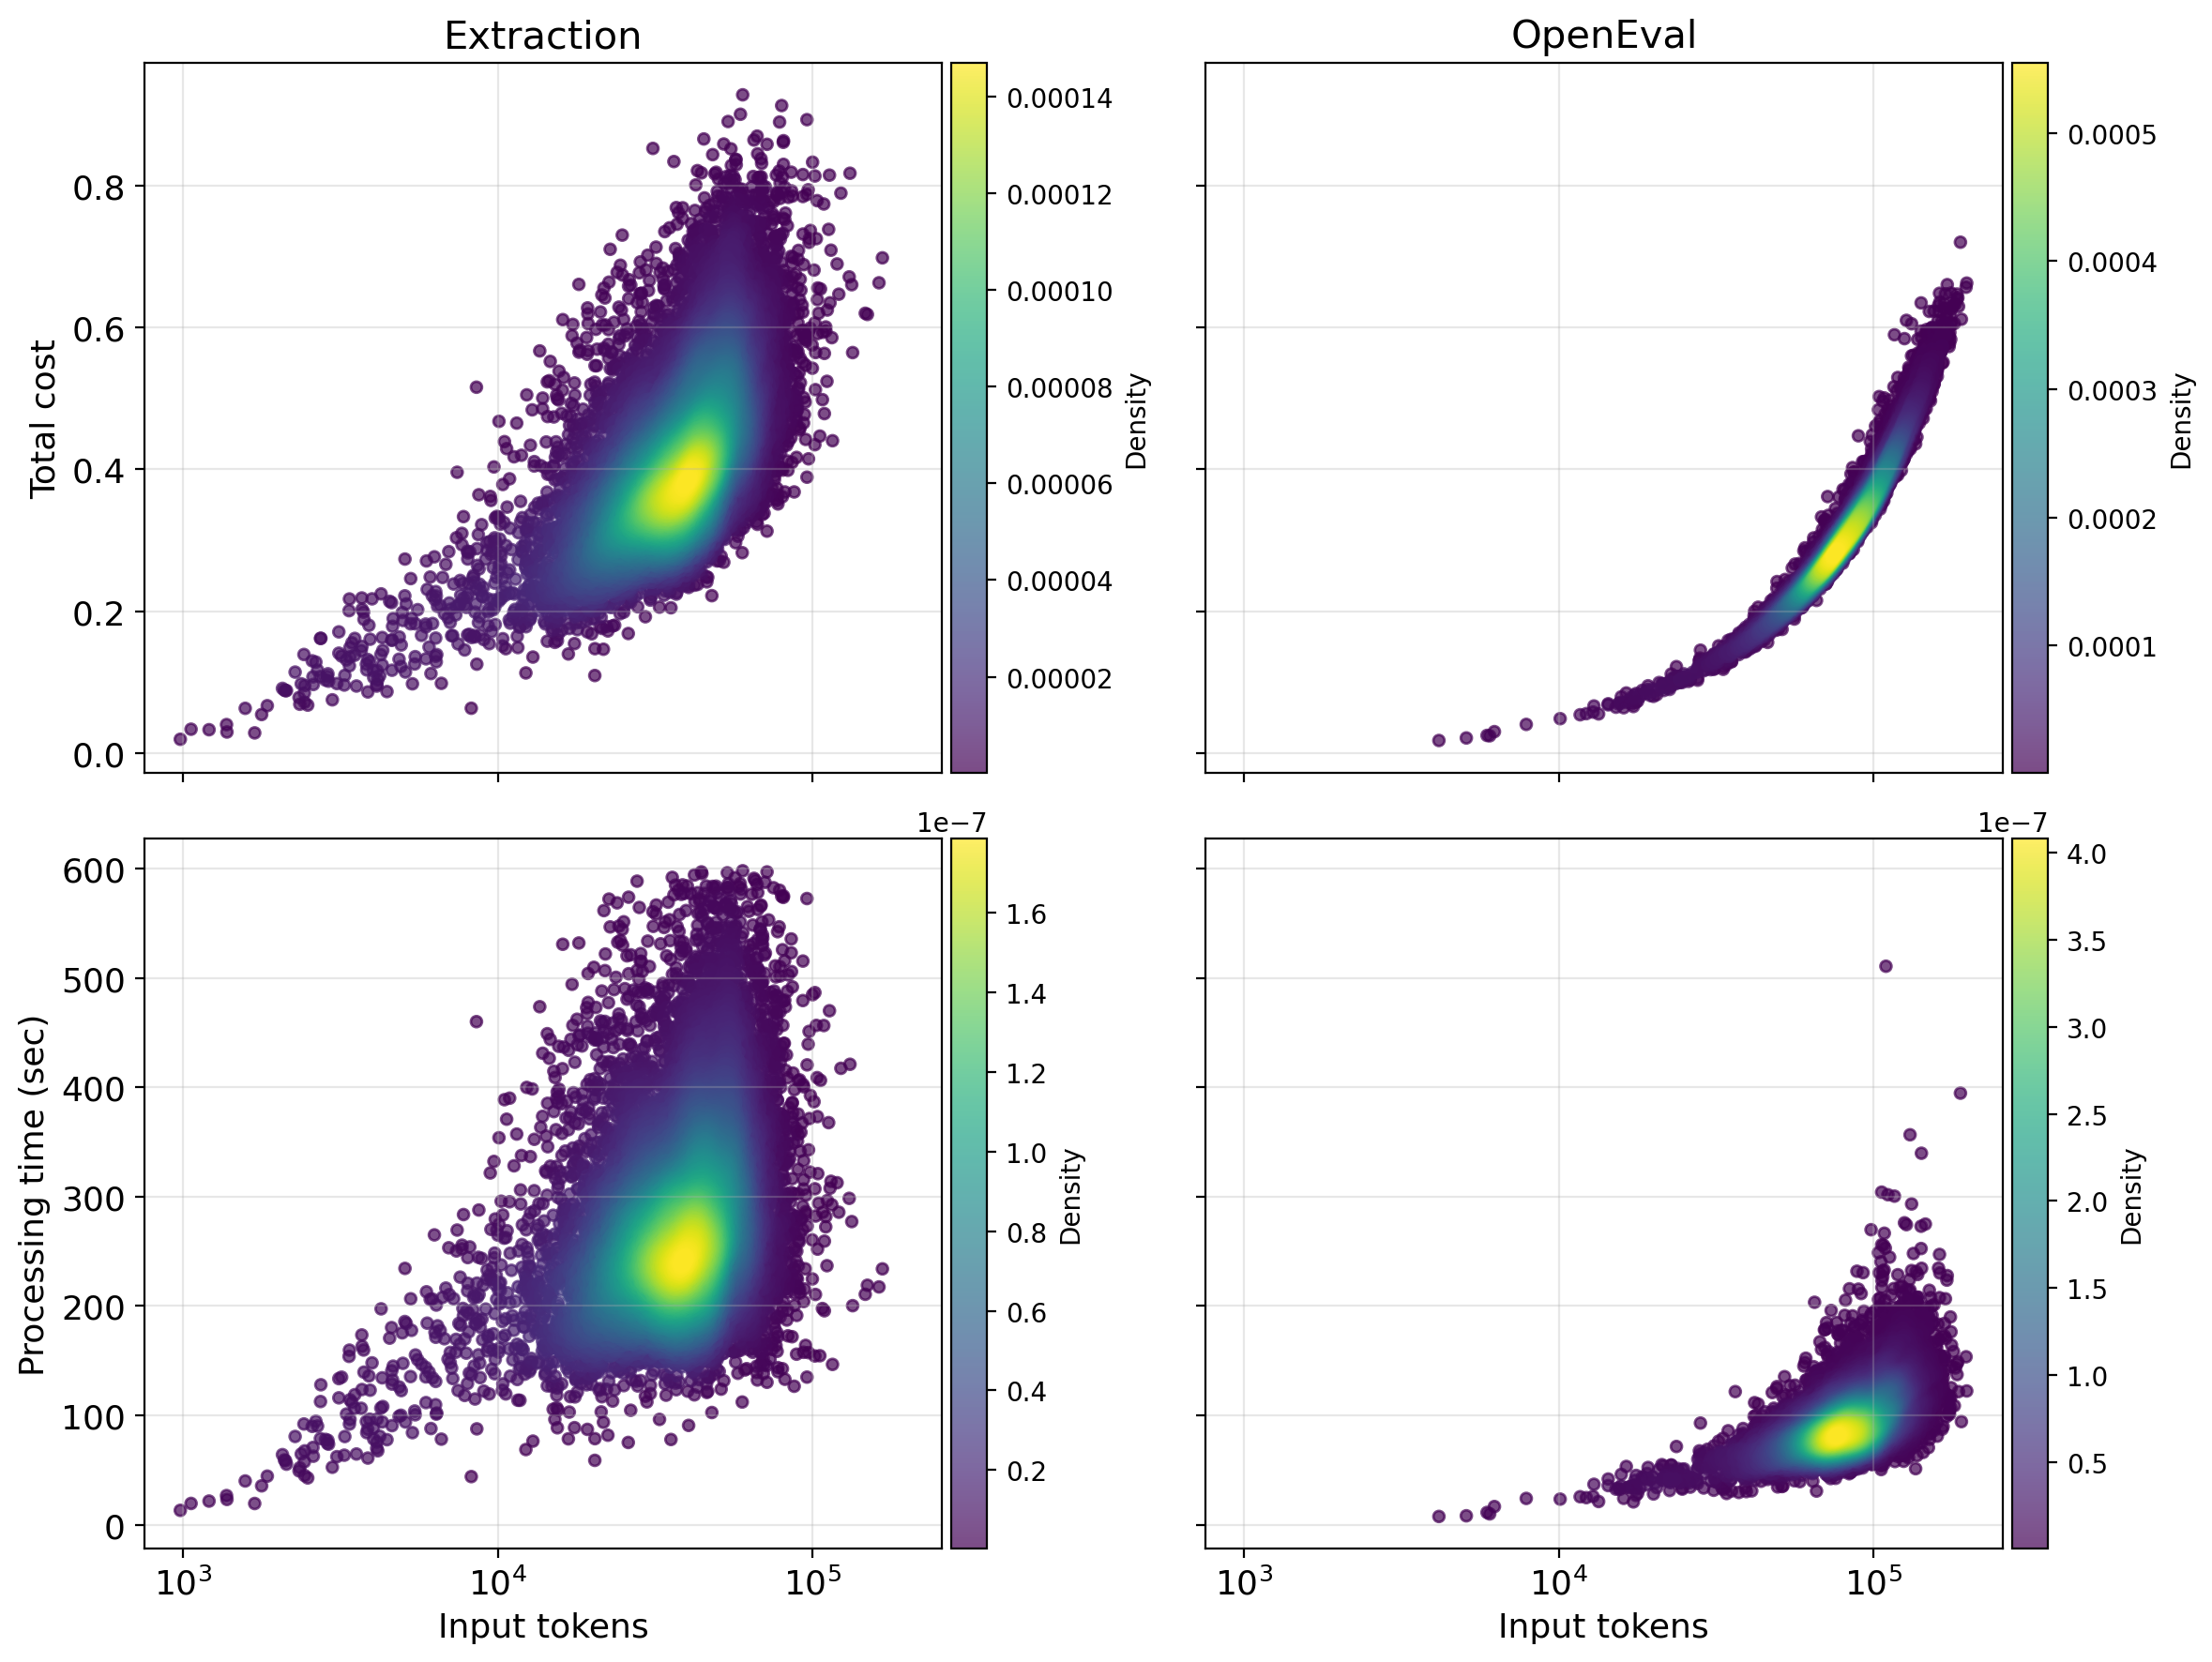

In [7]:
# Add KDE-based colormap scatter plots to show density

from scipy.stats import gaussian_kde
import numpy as np

fontsize = 13  # set fontsize here for all ticklabels, axis labels and titles (+2 for titles)

# Helper function to plot colored density scatter
def density_scatter(x, y, ax, cmap='viridis', **kwargs):
    xy = np.vstack([x, y])
    z = gaussian_kde(xy)(xy)
    idx = z.argsort()
    x, y, z = x[idx], y[idx], z[idx]
    sc = ax.scatter(x, y, c=z, cmap=cmap, **kwargs)
    return sc

# Create 2x2 layout with shared x and y axes
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(12, 9),
    sharex=True,
    sharey='row'  # Share y axis for each row (cost on top, time on bottom)
)

# --------------------------------
# Column 0: Extraction (left side)
# Column 1: OpenEval   (right side)
# Row 0: Cost vs input tokens
# Row 1: Time vs input tokens
# --------------------------------

# Cost vs input tokens - Extraction (Top left)
ax = axes[0, 0]
sc1 = density_scatter(
    df_metrics_extract["input_tokens"].values,
    df_metrics_extract["total_cost"].values,
    ax,
    alpha=0.7,
    s=18
)
ax.set_title("Extraction", fontsize=fontsize+2)
ax.set_ylabel("Total cost", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
plt.colorbar(sc1, ax=ax, label="Density", pad=0.01)
ax.tick_params(axis='both', which='both', labelsize=fontsize)

# Cost vs input tokens - OpenEval (Top right)
ax = axes[0, 1]
sc2 = density_scatter(
    df_metrics_eval_openeval["input_tokens"].values,
    df_metrics_eval_openeval["total_cost"].values,
    ax,
    alpha=0.7,
    s=18
)
ax.set_title("OpenEval", fontsize=fontsize+2)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
plt.colorbar(sc2, ax=ax, label="Density", pad=0.01)
ax.tick_params(axis='both', which='both', labelsize=fontsize)

# Time vs input tokens - Extraction (Bottom left)
ax = axes[1, 0]
sc3 = density_scatter(
    df_metrics_extract["input_tokens"].values,
    df_metrics_extract["processing_time_sec"].values,
    ax,
    alpha=0.7,
    s=18
)
ax.set_ylabel("Processing time (sec)", fontsize=fontsize)
ax.set_xlabel("Input tokens", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
plt.colorbar(sc3, ax=ax, label="Density", pad=0.01)
ax.tick_params(axis='both', which='both', labelsize=fontsize)

# Time vs input tokens - OpenEval (Bottom right)
ax = axes[1, 1]
sc4 = density_scatter(
    df_metrics_eval_openeval["input_tokens"].values,
    df_metrics_eval_openeval["processing_time_sec"].values,
    ax,
    alpha=0.7,
    s=18
)
ax.set_xlabel("Input tokens", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
plt.colorbar(sc4, ax=ax, label="Density", pad=0.01)
ax.tick_params(axis='both', which='both', labelsize=fontsize)

# Set row titles on left Y axes
axes[0, 0].set_ylabel("Total cost", fontsize=fontsize)
axes[1, 0].set_ylabel("Processing time (sec)", fontsize=fontsize)

plt.tight_layout()
# plt.savefig("figures/4_resource_analysis_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


Extraction - Total manuscripts: 16087
Extraction - Total cost: 6844.7655, avg per manuscript: 0.4255
Extraction - Total processing time (sec): 4510523.33, avg per manuscript: 280.38
OpenEval - Total manuscripts: 16087
OpenEval - Total cost: 5287.9445, avg per manuscript: 0.3287
OpenEval - Total processing time (sec): 1521565.50, avg per manuscript: 94.58


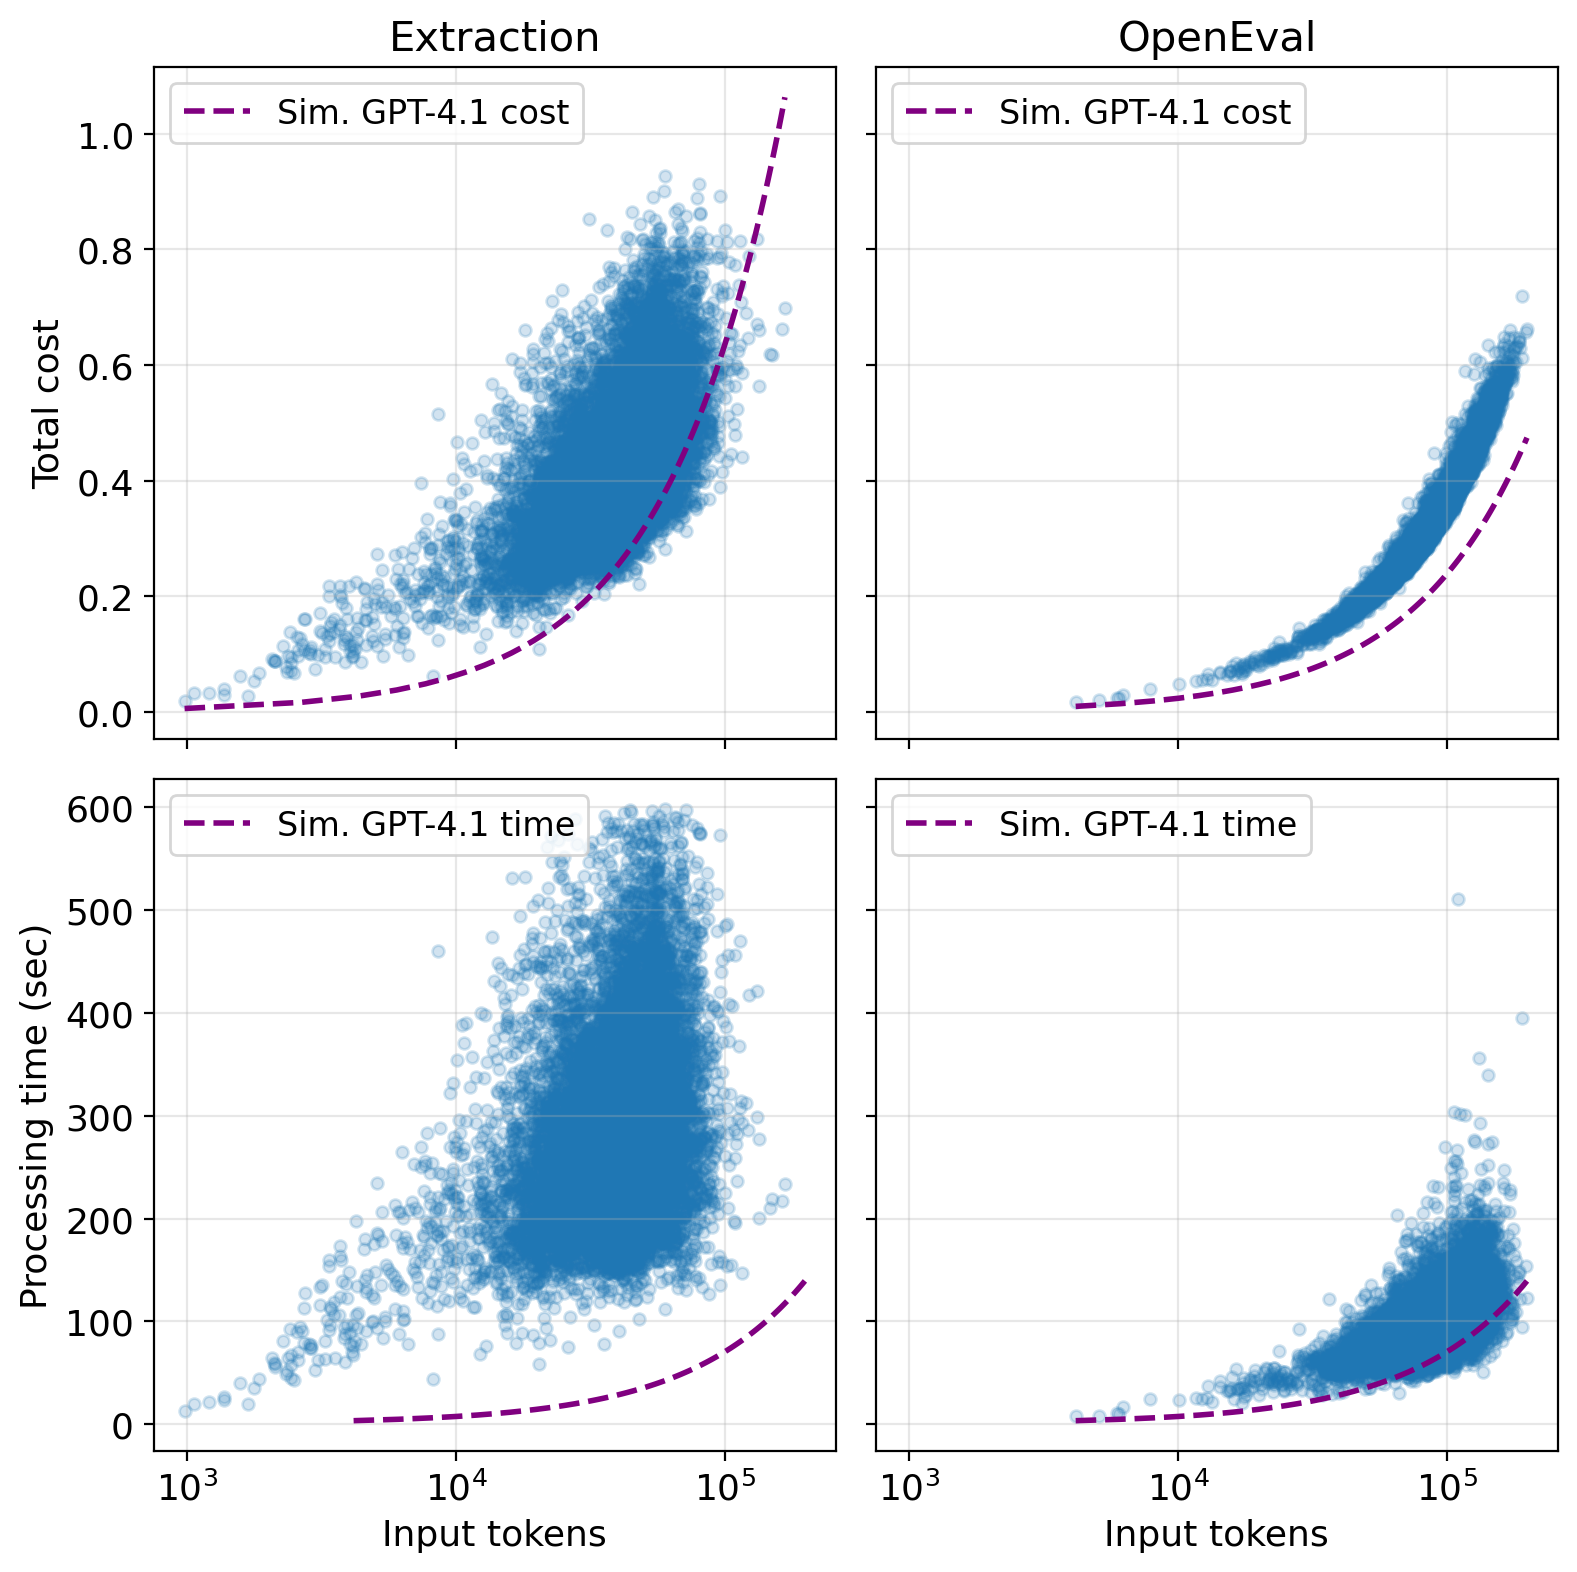

In [8]:
fontsize = 13  # set fontsize here for all ticklabels, axis labels and titles (+2 for titles)

# Print total and average time/cost per manuscript for Extraction
extract_total_cost = df_metrics_extract["total_cost"].sum()
extract_total_time = df_metrics_extract["processing_time_sec"].sum()
extract_manuscripts = df_metrics_extract["manuscript_id"].nunique()
extract_avg_cost = extract_total_cost / extract_manuscripts if extract_manuscripts > 0 else float('nan')
extract_avg_time = extract_total_time / extract_manuscripts if extract_manuscripts > 0 else float('nan')
print(f"Extraction - Total manuscripts: {extract_manuscripts}")
print(f"Extraction - Total cost: {extract_total_cost:.4f}, avg per manuscript: {extract_avg_cost:.4f}")
print(f"Extraction - Total processing time (sec): {extract_total_time:.2f}, avg per manuscript: {extract_avg_time:.2f}")

# Print total and average time/cost per manuscript for OpenEval
eval_total_cost = df_metrics_eval_openeval["total_cost"].sum()
eval_total_time = df_metrics_eval_openeval["processing_time_sec"].sum()
eval_manuscripts = df_metrics_eval_openeval["manuscript_id"].nunique()
eval_avg_cost = eval_total_cost / eval_manuscripts if eval_manuscripts > 0 else float('nan')
eval_avg_time = eval_total_time / eval_manuscripts if eval_manuscripts > 0 else float('nan')
print(f"OpenEval - Total manuscripts: {eval_manuscripts}")
print(f"OpenEval - Total cost: {eval_total_cost:.4f}, avg per manuscript: {eval_avg_cost:.4f}")
print(f"OpenEval - Total processing time (sec): {eval_total_time:.2f}, avg per manuscript: {eval_avg_time:.2f}")

# ----- Simulated GPT-4.1 cost/time lines -----
# GPT-4.1 pricing: Input - $0.0020 per 1K tokens, Output - $0.0080 per 1K tokens
gpt41_input_token_cost = 0.0020 / 1000
gpt41_output_token_cost = 0.0080 / 1000

# Calculate simulated GPT-4.1 total cost for all points in both datasets
# (use actual input/output tokens, but apply GPT-4.1 pricing!)
def simulate_gpt41_cost(df):
    return df["input_tokens"] * gpt41_input_token_cost + df["output_tokens"] * gpt41_output_token_cost

# Simulate GPT-4.1 expected times (assume ~70 tokens/sec for output tokens, input negligible for eval)
# This is a simplification as real API latency includes overhead, etc.
gpt4o_tokens_per_sec = 70.0  # conservative, from prompt
def simulate_gpt41_time(df):
    # Time is dominated by output generation; add a small fixed overhead for realism
    fixed_overhead_sec = 0.5
    return (df["output_tokens"] / gpt4o_tokens_per_sec) + fixed_overhead_sec

# Create 2x2 layout with shared x and y axes
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(8, 8),
    sharex=True,
    sharey='row'  # Share y axis for each row (cost on top, time on bottom)
)

# --------------------------------
# Column 0: Extraction (left side)
# Column 1: OpenEval   (right side)
# Row 0: Cost vs input tokens
# Row 1: Time vs input tokens
# --------------------------------

# Cost vs input tokens - Extraction (Top left)
ax = axes[0, 0]
ax.scatter(
    df_metrics_extract["input_tokens"].values,
    df_metrics_extract["total_cost"].values,
    alpha=0.2,
    s=18
)
# Simulated GPT-4.1 line
input_range = np.linspace(
    df_metrics_extract["input_tokens"].min(),
    df_metrics_extract["input_tokens"].max(),
    100
)
# For simplicity, fix output_tokens/input_tokens ratio at the mean for simulation
mean_output_per_input = (df_metrics_extract["output_tokens"] / df_metrics_extract["input_tokens"]).replace([np.inf, -np.inf], np.nan).fillna(0).mean()
sim_output_tokens = input_range * mean_output_per_input
sim_gpt41_cost = input_range * gpt41_input_token_cost + sim_output_tokens * gpt41_output_token_cost
ax.plot(
    input_range,
    sim_gpt41_cost,
    color='purple',
    linestyle='--',
    linewidth=2,
    label='Sim. GPT-4.1 cost'
)
ax.set_title("Extraction", fontsize=fontsize+2)
ax.set_ylabel("Total cost", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
ax.legend(fontsize=fontsize-1, loc='upper left')

# Cost vs input tokens - OpenEval (Top right)
ax = axes[0, 1]
ax.scatter(
    df_metrics_eval_openeval["input_tokens"].values,
    df_metrics_eval_openeval["total_cost"].values,
    alpha=0.2,
    s=18
)
# Simulated GPT-4.1 line
input_range = np.linspace(
    df_metrics_eval_openeval["input_tokens"].min(),
    df_metrics_eval_openeval["input_tokens"].max(),
    100
)
mean_output_per_input = (df_metrics_eval_openeval["output_tokens"] / df_metrics_eval_openeval["input_tokens"]).replace([np.inf, -np.inf], np.nan).fillna(0).mean()
sim_output_tokens = input_range * mean_output_per_input
sim_gpt41_cost = input_range * gpt41_input_token_cost + sim_output_tokens * gpt41_output_token_cost
ax.plot(
    input_range,
    sim_gpt41_cost,
    color='purple',
    linestyle='--',
    linewidth=2,
    label='Sim. GPT-4.1 cost'
)
ax.set_title("OpenEval", fontsize=fontsize+2)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
ax.legend(fontsize=fontsize-1, loc='upper left')

# Time vs input tokens - Extraction (Bottom left)
ax = axes[1, 0]
ax.scatter(
    df_metrics_extract["input_tokens"].values,
    df_metrics_extract["processing_time_sec"].values,
    alpha=0.2,
    s=18
)
# Plot simulated GPT-4.1 time (using mean output/input ratio)
sim_gpt41_time = (sim_output_tokens / gpt4o_tokens_per_sec) + 0.5
ax.plot(
    input_range,
    sim_gpt41_time,
    color='purple',
    linestyle='--',
    linewidth=2,
    label='Sim. GPT-4.1 time'
)
ax.set_ylabel("Processing time (sec)", fontsize=fontsize)
ax.set_xlabel("Input tokens", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
ax.legend(fontsize=fontsize-1, loc='upper left')

# Time vs input tokens - OpenEval (Bottom right)
ax = axes[1, 1]
ax.scatter(
    df_metrics_eval_openeval["input_tokens"].values,
    df_metrics_eval_openeval["processing_time_sec"].values,
    alpha=0.2,
    s=18
)
sim_gpt41_time = (sim_output_tokens / gpt4o_tokens_per_sec) + 0.5
ax.plot(
    input_range,
    sim_gpt41_time,
    color='purple',
    linestyle='--',
    linewidth=2,
    label='Sim. GPT-4.1 time'
)
ax.set_xlabel("Input tokens", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
ax.legend(fontsize=fontsize-1, loc='upper left')

# Set row titles on left Y axes
axes[0, 0].set_ylabel("Total cost", fontsize=fontsize)
axes[1, 0].set_ylabel("Processing time (sec)", fontsize=fontsize)

plt.tight_layout()
# plt.savefig("figures/4_resource_analysis_scatter.png", dpi=300, bbox_inches='tight')
plt.show()


Extraction - Total manuscripts: 16087
Extraction - Total cost: 6844.7655, avg per manuscript: 0.4255
Extraction - Total processing time (sec): 4510523.33, avg per manuscript: 280.38
OpenEval - Total manuscripts: 16087
OpenEval - Total cost: 5287.9445, avg per manuscript: 0.3287
OpenEval - Total processing time (sec): 1521565.50, avg per manuscript: 94.58


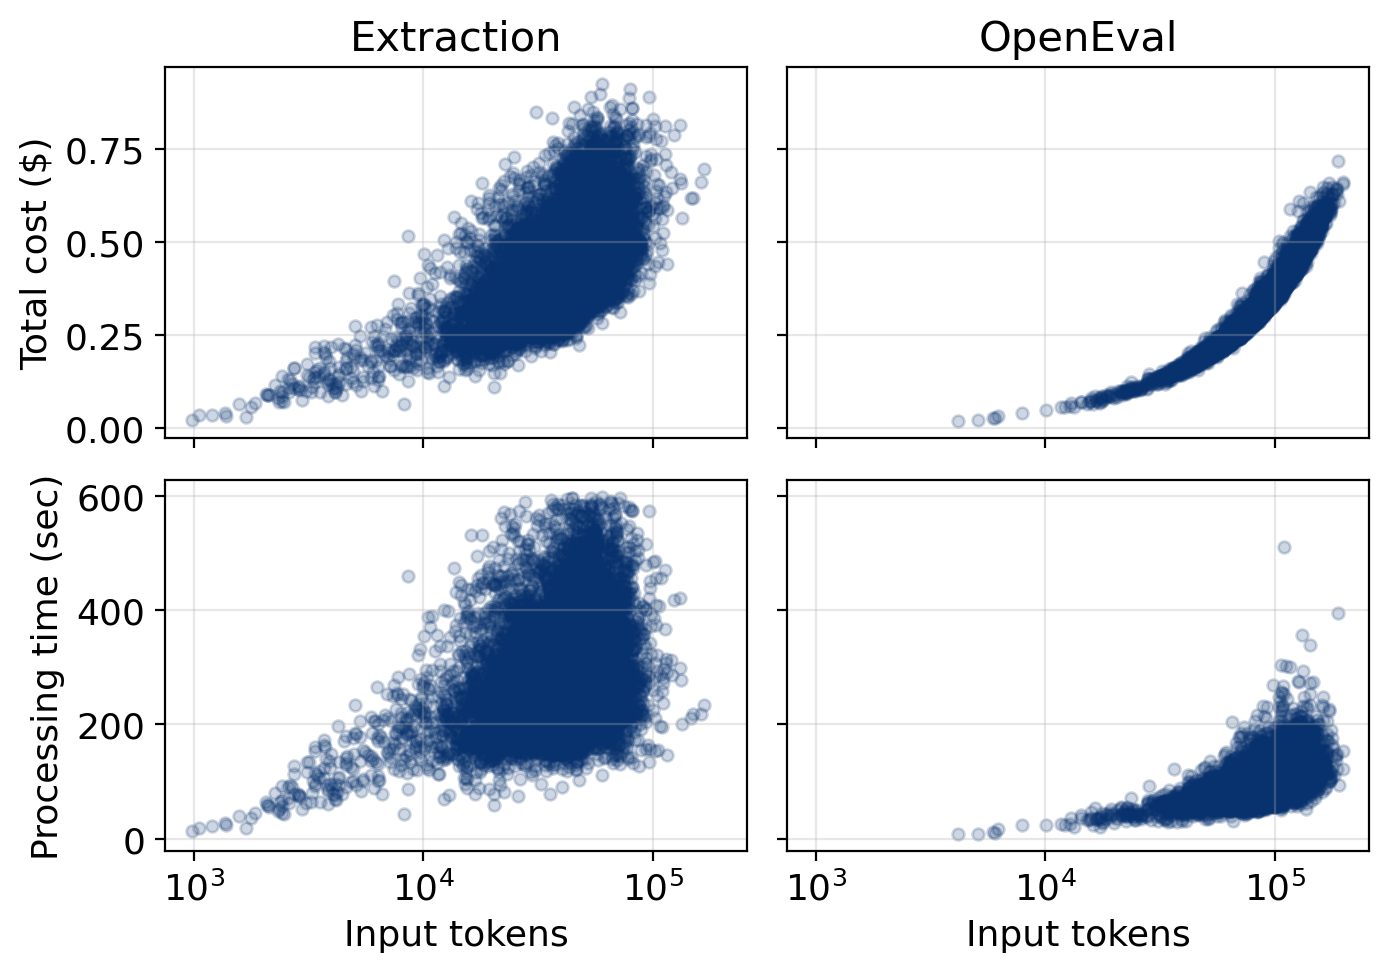

In [9]:
fontsize = 13  # set fontsize here for all ticklabels, axis labels and titles (+2 for titles)
scatter_color = plt.get_cmap('Blues')(0.99)

# Print total and average time/cost per manuscript for Extraction
extract_total_cost = df_metrics_extract["total_cost"].sum()
extract_total_time = df_metrics_extract["processing_time_sec"].sum()
extract_manuscripts = df_metrics_extract["manuscript_id"].nunique()
extract_avg_cost = extract_total_cost / extract_manuscripts if extract_manuscripts > 0 else float('nan')
extract_avg_time = extract_total_time / extract_manuscripts if extract_manuscripts > 0 else float('nan')
print(f"Extraction - Total manuscripts: {extract_manuscripts}")
print(f"Extraction - Total cost: {extract_total_cost:.4f}, avg per manuscript: {extract_avg_cost:.4f}")
print(f"Extraction - Total processing time (sec): {extract_total_time:.2f}, avg per manuscript: {extract_avg_time:.2f}")

# Print total and average time/cost per manuscript for OpenEval
eval_total_cost = df_metrics_eval_openeval["total_cost"].sum()
eval_total_time = df_metrics_eval_openeval["processing_time_sec"].sum()
eval_manuscripts = df_metrics_eval_openeval["manuscript_id"].nunique()
eval_avg_cost = eval_total_cost / eval_manuscripts if eval_manuscripts > 0 else float('nan')
eval_avg_time = eval_total_time / eval_manuscripts if eval_manuscripts > 0 else float('nan')
print(f"OpenEval - Total manuscripts: {eval_manuscripts}")
print(f"OpenEval - Total cost: {eval_total_cost:.4f}, avg per manuscript: {eval_avg_cost:.4f}")
print(f"OpenEval - Total processing time (sec): {eval_total_time:.2f}, avg per manuscript: {eval_avg_time:.2f}")

# Create 2x2 layout with shared x and y axes
fig, axes = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(7, 5),
    sharex=True,
    sharey='row'  # Share y axis for each row (cost on top, time on bottom)
)

# --------------------------------
# Column 0: Extraction (left side)
# Column 1: OpenEval   (right side)
# Row 0: Cost vs input tokens
# Row 1: Time vs input tokens
# --------------------------------

# Cost vs input tokens - Extraction (Top left)
ax = axes[0, 0]
ax.scatter(
    df_metrics_extract["input_tokens"].values,
    df_metrics_extract["total_cost"].values,
    alpha=0.2,
    s=18,
    color=scatter_color
)
ax.set_title("Extraction", fontsize=fontsize+2)
ax.set_ylabel("Total cost ($)", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
# ax.legend([],[],fontsize=fontsize-1, loc='upper left') # no legend

# Cost vs input tokens - OpenEval (Top right)
ax = axes[0, 1]
ax.scatter(
    df_metrics_eval_openeval["input_tokens"].values,
    df_metrics_eval_openeval["total_cost"].values,
    alpha=0.2,
    s=18,
    color=scatter_color
)
ax.set_title("OpenEval", fontsize=fontsize+2)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
# ax.legend([],[],fontsize=fontsize-1, loc='upper left') # no legend

# Time vs input tokens - Extraction (Bottom left)
ax = axes[1, 0]
ax.scatter(
    df_metrics_extract["input_tokens"].values,
    df_metrics_extract["processing_time_sec"].values,
    alpha=0.2,
    s=18,
    color=scatter_color
)
ax.set_ylabel("Processing time (sec)", fontsize=fontsize)
ax.set_xlabel("Input tokens", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
# ax.legend([],[],fontsize=fontsize-1, loc='upper left') # no legend

# Time vs input tokens - OpenEval (Bottom right)
ax = axes[1, 1]
ax.scatter(
    df_metrics_eval_openeval["input_tokens"].values,
    df_metrics_eval_openeval["processing_time_sec"].values,
    alpha=0.2,
    s=18,
    color=scatter_color
)
ax.set_xlabel("Input tokens", fontsize=fontsize)
ax.grid(alpha=0.3)
ax.set_xscale("symlog")
ax.tick_params(axis='both', which='both', labelsize=fontsize)
# ax.legend([],[],fontsize=fontsize-1, loc='upper left') # no legend

# Set row titles on left Y axes
axes[0, 0].set_ylabel("Total cost ($)", fontsize=fontsize)
axes[1, 0].set_ylabel("Processing time (sec)", fontsize=fontsize)

plt.tight_layout()
plt.savefig("figures/4_resource_analysis_scatter.png", dpi=300, bbox_inches='tight')
plt.show()
